# Household Power Consumption Forecasting
Forecasting daily household power usage using ARIMA, SARIMA, and Holt-Winters.

## 1. Load & Clean Data
Raw data is minute-level, ~2M rows. `?` markers are converted to NaN on load.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df=pd.read_csv("household_power_consumption.txt", sep=";", na_values="?")

In [35]:
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


Combine `Date` + `Time` into a proper datetime index — required for resampling.

In [37]:
df['DateTime']=pd.to_datetime(df['Date']+" "+df['Time'],format="%d/%m/%Y %H:%M:%S")

In [38]:
df.set_index("DateTime", inplace=True)

## 2. Resample to Daily
Resampled to **daily mean** (not sum — mean is robust to partial-day sensor gaps).

**Leakage note:** `Voltage`, `Global_intensity`, and `Sub_metering_1/2/3` are excluded from all modeling — algebraically derived from or summing into the target, and unavailable at real forecast time anyway.

In [39]:
df_daily = df.resample("D")["Global_active_power"].mean()

### Missing Value Check

In [40]:
df_daily.isnull().sum()

np.int64(9)

In [41]:
missing_mask=df_daily.isna()

In [42]:
missing_dates = df_daily.index[missing_mask]

In [43]:
missing_dates

DatetimeIndex(['2007-04-29', '2009-06-14', '2010-01-13', '2010-08-18',
               '2010-08-19', '2010-08-20', '2010-08-21', '2010-09-26',
               '2010-09-27'],
              dtype='datetime64[ns]', name='DateTime', freq=None)

8 of 1,442 days missing (4 isolated, 1 four-day cluster in Aug 2010). Linearly interpolated — gaps are short and don't span a full weekly cycle.

In [44]:
df_daily = df_daily.interpolate(method="linear")

In [45]:
df_daily.isna().sum()

np.int64(0)

## 3. EDA — Trend & Seasonality

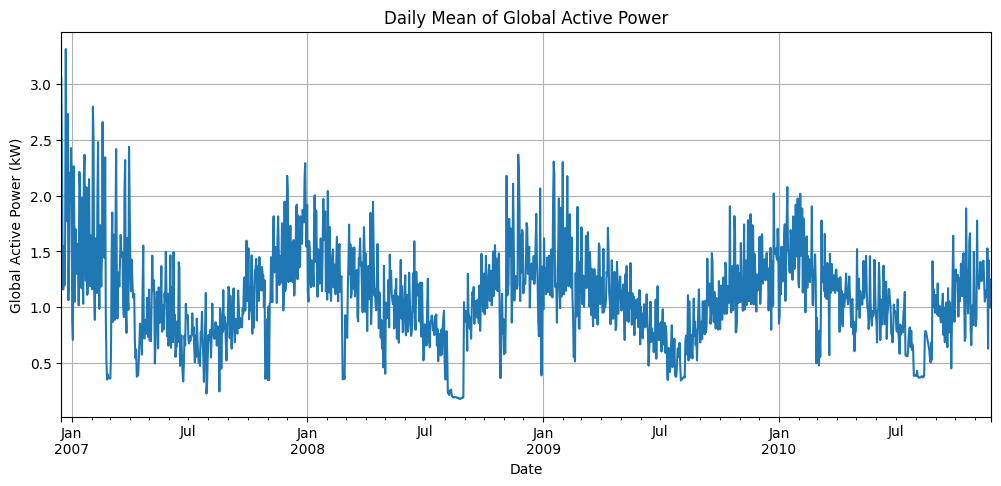

In [46]:
df_daily.plot(kind='line',figsize=(12,5), title="Daily Mean of Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")
plt.grid(True)
plt.show()

In [47]:
df_daily = pd.DataFrame(df_daily)

365-day rolling average isolates long-term trend by averaging out one full seasonal cycle.

In [48]:
df_daily['rolling_avg']=df_daily['Global_active_power'].rolling(window=365).mean()

**Finding:** trend line is flat (~1.0–1.15 kW) across all 4 years — no significant long-term drift. Visible variation is seasonal, not trend.

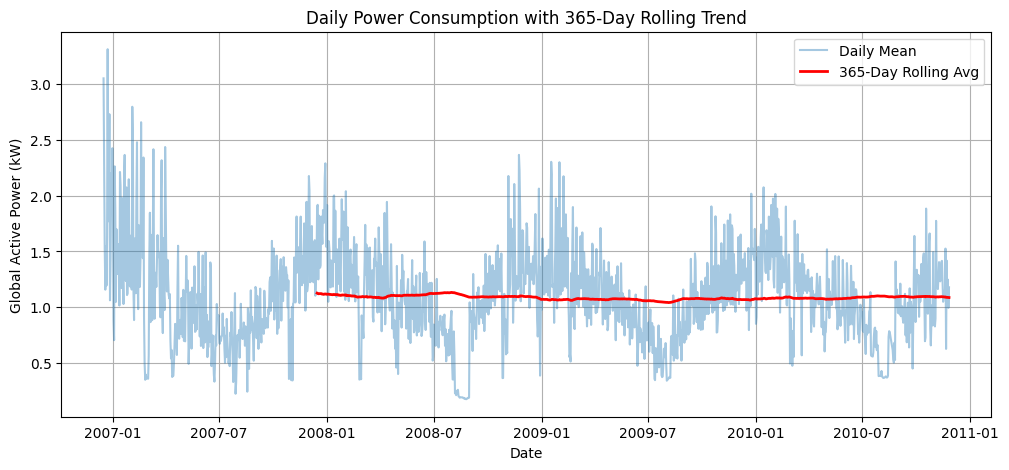

In [49]:
plt.figure(figsize=(12,5))
plt.plot(df_daily.index, df_daily['Global_active_power'], label='Daily Mean', alpha=0.4)
plt.plot(df_daily.index, df_daily['rolling_avg'], label='365-Day Rolling Avg', color='red', linewidth=2)
plt.title('Daily Power Consumption with 365-Day Rolling Trend')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

## 4. Train/Test Split
Chronological split. Test set = final full year (2009-11-26 → 2010-11-26), covering one complete seasonal cycle.

In [50]:
train = df_daily.loc[:'2009-11-25']
test = df_daily.loc['2009-11-26':]

In [51]:
train.shape

(1076, 2)

In [52]:
test.shape

(366, 2)

## 5. Stationarity Check
ADF test fit on **train only** — fitting on test would leak future distribution info into preprocessing.

In [53]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train['Global_active_power'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -3.184339934405372
p-value: 0.02090922906030922


**Result:** p = 0.021 → stationary → `d=0`.

### ACF/PACF — Selecting ARIMA Order
PACF cuts off sharply after lag-1 (secondary isolated spike at lag-7) → AR-dominated. ACF decays gradually → minimal MA needed.

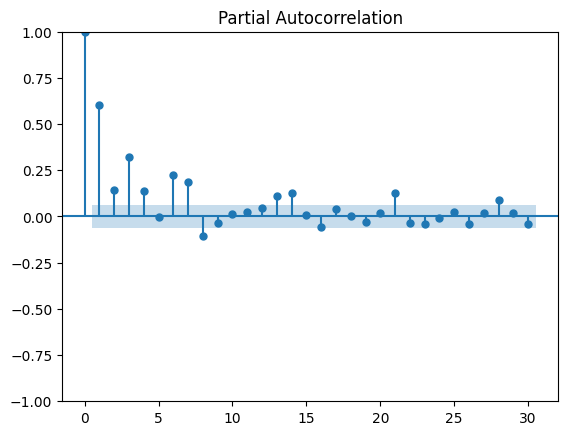

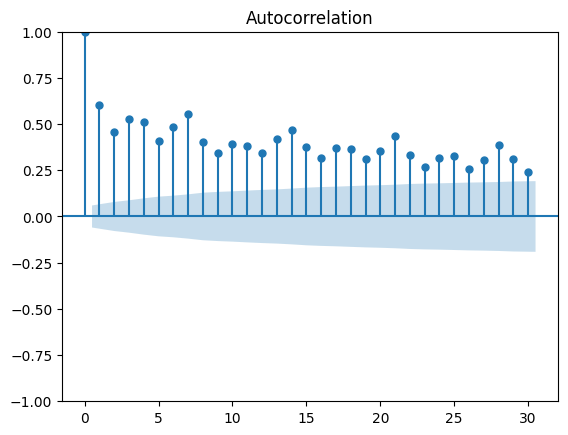

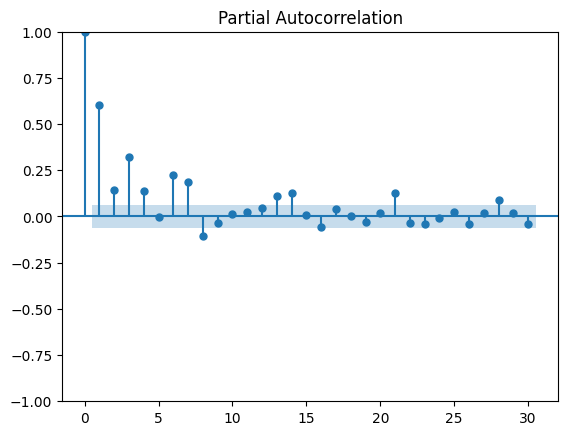

In [54]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(train['Global_active_power'],lags=30)
plot_pacf(train['Global_active_power'], lags=30)

## 6. ARIMA(1,0,0)

In [55]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train['Global_active_power'], order=(1,0,0))
fitted_model=model.fit()

In [56]:
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                SARIMAX Results                                
===============================================================================
Dep. Variable:     Global_active_power   No. Observations:                 1076
Model:                  ARIMA(1, 0, 0)   Log Likelihood                -398.157
Date:                 Wed, 22 Jul 2026   AIC                            802.313
Time:                         01:18:32   BIC                            817.256
Sample:                     12-16-2006   HQIC                           807.972
                          - 11-25-2009                                         
Covariance Type:                   opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0957      0.033     33.628      0.000       1.032       1.160
ar.L1          0.6161      0.021     29.757      0.000       0.575       0.657
sigma2         0.1227      0.004     29.660      0.000       0.115       0.131
===================================================================================
Ljung-Box (L1) (Q):                  10.97   Jarque-Bera (JB):               389.75
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.51   Skew:                             0.94
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.27
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## 7. SARIMA — Adding Weekly Seasonality
Ljung-Box on ARIMA residuals showed significant leftover autocorrelation at lag-7. Testing whether a seasonal term (`m=7`) resolves it.

In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train['Global_active_power'],
    order=(1,0,0),
    seasonal_order=(1,0,0,7)
)
sarima_fitted = sarima_model.fit()

In [58]:
sarima_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                     
=========================================================================================
Dep. Variable:               Global_active_power   No. Observations:                 1076
Model:             SARIMAX(1, 0, 0)x(1, 0, 0, 7)   Log Likelihood                -446.432
Date:                           Wed, 22 Jul 2026   AIC                            898.863
Time:                                   01:18:32   BIC                            913.806
Sample:                               12-16-2006   HQIC                           904.522
                                    - 11-25-2009                                         
Covariance Type:                             opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8955      0.011     81.931      0.000       0.874       0.917
ar.S.L7        0.3423      0.025     13.850      0.000       0.294       0.391
sigma2         0.1339      0.004     32.348      0.000       0.126       0.142
===================================================================================
Ljung-Box (L1) (Q):                 119.51   Jarque-Bera (JB):               171.31
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.51   Skew:                             0.20
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

Checking residuals across multiple seasonal lags (7/14/21), not just the default lag-1 in `.summary()`.

In [59]:
from statsmodels.stats.diagnostic import acorr_ljungbox

residuals = sarima_fitted.resid
ljung_result = acorr_ljungbox(residuals, lags=[7, 14, 21], return_df=True)
print(ljung_result)

       lb_stat     lb_pvalue
7   194.524380  1.655930e-38
14  201.345877  2.916385e-35
21  236.171753  2.418695e-38


## 8. Holt-Winters (Exponential Smoothing)
A structurally different, decomposition-based approach for a genuine methodology comparison.

In [60]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train['Global_active_power'],
    trend=None,
    seasonal='add',
    seasonal_periods=7
).fit()

## 9. Evaluation — Forecast Accuracy on Test Set
In-sample fit diagnostics don't guarantee forecast quality on unseen data — RMSE on `test` is the real comparison.

In [61]:
hw_forecast = hw_model.forecast(steps=len(test))

In [62]:
arima_forecast = fitted_model.forecast(steps=len(test))
sarima_forecast = sarima_fitted.forecast(steps=len(test))

In [63]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(test['Global_active_power'], arima_forecast))
rmse_sarima = np.sqrt(mean_squared_error(test['Global_active_power'], sarima_forecast))
rmse_hw = np.sqrt(mean_squared_error(test['Global_active_power'], hw_forecast))

print("ARIMA RMSE:", rmse_arima)
print("SARIMA RMSE:", rmse_sarima)
print("Holt-Winters RMSE:", rmse_hw)

ARIMA RMSE: 0.3466623061297389
SARIMA RMSE: 1.1063474118782142
Holt-Winters RMSE: 0.4736605742382218


| Model | RMSE (kW) |
|---|---|
| **ARIMA(1,0,0)** | **0.347** |
| Holt-Winters | 0.474 |
| SARIMA(1,0,0)(1,0,0,7) | 1.106 |

**Finding:** despite SARIMA's seasonal coefficient being significant in-sample, its out-of-sample RMSE was 3x worse — likely compounding seasonal extrapolation error. **ARIMA(1,0,0) wins and is deployed.**

## 10. Save Winning Model for Deployment

In [64]:
fitted_model.save('arima_model.pkl')